# Hábitos de vida y rendimiento académico

| Campo | Detalle |
|---|---|
| **Autor** | [Borja Mora Méndez](https://www.linkedin.com/in/borja-mora-mendez/) |
| **Contacto** | borja.mora.mendez@gmail.com |
| **Categoría** | Python > Análisis Exploratorio (EDA) |
| **Técnica principal** | pandas (groupby, cut, corr), visualización con matplotlib/seaborn |
| **Dataset** | `habitos_estudiantes.csv` — 50 estudiantes universitarios |
| **Última actualización** | julio 2026 |

---

## Contexto de negocio

El servicio de orientación académica de una universidad quiere entender qué hábitos de
vida (horas de estudio, sueño, redes sociales, ejercicio, café) están realmente
relacionados con el rendimiento en examen, para diseñar un programa de tutorías dirigido
a los estudiantes con más riesgo de suspender.

**Pregunta analítica:** ¿qué hábitos predicen mejor la nota de examen, y qué perfil
distingue a un estudiante de alto rendimiento de uno de bajo rendimiento?


### Carga de librerías y datos


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

In [2]:
dp = pd.read_csv("habitos_estudiantes.csv")
dp.head()


,student_id,age,study_hours,sleep_hours,social_media_hours,exercise_hours,coffee_cups,exam_score,date
0,1,20,2.5,6,3.0,1.0,2,65,2024-01-01
1,2,22,5.0,7,2.0,0.5,3,78,2024-01-02
2,3,19,1.0,5,4.5,0.0,1,50,2024-01-03
3,4,21,4.0,8,1.5,1.5,2,82,2024-01-04
4,5,23,6.0,7,1.0,0.5,4,88,2024-01-05


### 1. Diagnóstico inicial del dataset


In [3]:
dp.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          50 non-null     int64  
 1   age                 50 non-null     int64  
 2   study_hours         50 non-null     float64
 3   sleep_hours         50 non-null     int64  
 4   social_media_hours  50 non-null     float64
 5   exercise_hours      50 non-null     float64
 6   coffee_cups         50 non-null     int64  
 7   exam_score          50 non-null     int64  
 8   date                50 non-null     object 
dtypes: float64(3), int64(5), object(1)
memory usage: 3.6+ KB


In [4]:
# Duplicados exactos (esto faltaba en el diagnóstico inicial)
print("Filas duplicadas:", dp.duplicated().sum())


Filas duplicadas: 0


In [5]:
# Nulos: total general y porcentaje por columna
print("Total de nulos en todo el dataset:", dp.isna().sum().sum())
print()
print("Porcentaje de nulos por columna:")
print((dp.isna().sum() / len(dp) * 100).round(2))


Total de nulos en todo el dataset: 0

Porcentaje de nulos por columna:
student_id            0.0
age                   0.0
study_hours           0.0
sleep_hours           0.0
social_media_hours    0.0
exercise_hours        0.0
coffee_cups           0.0
exam_score            0.0
date                  0.0
dtype: float64


### 2. Estadística descriptiva por variable


In [6]:
dp.describe()


,student_id,age,study_hours,sleep_hours,social_media_hours,exercise_hours,coffee_cups,exam_score
count,50.00000,50.000000,50.00000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,20.900000,4.30000,6.56000,2.540000,0.720000,2.660000,75.280000
std,14.57738,1.297564,1.91929,1.01338,1.300863,0.486134,1.364417,14.116194
min,1.00000,19.000000,1.00000,5.00000,1.000000,0.000000,1.000000,47.000000
25%,13.25000,20.000000,2.62500,6.00000,1.500000,0.500000,2.000000,65.750000
50%,25.50000,21.000000,4.25000,7.00000,2.250000,1.000000,2.000000,77.500000
75%,37.75000,22.000000,6.00000,7.00000,3.500000,1.000000,4.000000,87.750000
max,50.00000,23.000000,7.50000,8.00000,5.000000,1.500000,5.000000,96.000000


In [7]:
# Medias individuales de cada variable

media_años = np.mean(dp["age"])
media_horas_estudio = np.mean(dp["study_hours"])
media_horas_sueño = np.mean(dp["sleep_hours"])
media_horas_sm = np.mean(dp["social_media_hours"])
media_horas_ejercicios = np.mean(dp["exercise_hours"])
media_cafes = np.mean(dp["coffee_cups"])
media_notas = np.mean(dp["exam_score"])


In [8]:
## Resumen final de medias

print("Media de años:", media_años,
      "\nMedia de horas de estudio:", media_horas_estudio,
      "\nMedia de horas de sueño:", media_horas_sueño,
      "\nMedia de horas en redes sociales:", media_horas_sm,
      "\nMedia de horas haciendo ejercicio:", media_horas_ejercicios,
      "\nMedia de cafés diarios:", media_cafes,
      "\nMedia de notas de examen:", media_notas)


Media de años: 20.9 
Media de horas de estudio: 4.3 
Media de horas de sueño: 6.56 
Media de horas en redes sociales: 2.54 
Media de horas haciendo ejercicio: 0.72 
Media de cafés diarios: 2.66 
Media de notas de examen: 75.28


### 3. Alumnos destacados según su nota


In [9]:
# Alumno con mayor y menor puntuación (nombres distintos, ya no se pisan)

mejor_alumno = dp.loc[dp["exam_score"].idxmax()]
peor_alumno = dp.loc[dp["exam_score"].idxmin()]

print(mejor_alumno)
print()
print(peor_alumno)


student_id                    34
age                           23
study_hours                  7.5
sleep_hours                    7
social_media_hours           1.0
exercise_hours               1.0
coffee_cups                    5
exam_score                    96
date                  2024-02-03
Name: 33, dtype: object

student_id                    43
age                           19
study_hours                  1.0
sleep_hours                    5
social_media_hours           5.0
exercise_hours               0.0
coffee_cups                    1
exam_score                    47
date                  2024-02-12
Name: 42, dtype: object


In [10]:
# Top 5 y bottom 5

top_5 = dp.nlargest(5, "exam_score")
bottom_5 = dp.nsmallest(5, "exam_score")

print(top_5)
print()
print(bottom_5)


    student_id  age  study_hours  sleep_hours  social_media_hours  \
33          34   23          7.5            7                 1.0   
13          14   23          7.5            7                 1.0   
41          42   22          7.0            8                 1.0   
21          22   22          7.0            8                 1.0   
47          48   23          7.0            7                 1.0   

    exercise_hours  coffee_cups  exam_score        date  
33             1.0            5          96  2024-02-03  
13             1.0            5          95  2024-01-14  
41             1.5            5          94  2024-02-11  
21             1.5            5          93  2024-01-22  
47             1.0            5          93  2024-02-17  

    student_id  age  study_hours  sleep_hours  social_media_hours  \
42          43   19          1.0            5                 5.0   
22          23   19          1.0            5                 5.0   
2            3   19          

### 4. Distribución de estudiantes por cada variable (total y %)


In [11]:
# Total de alumnos (usando len(), no count_nonzero)

total_alumnos = len(dp)
print(total_alumnos)


50


In [12]:
# Total de estudiantes por edad, con %

años_dp = dp.groupby("age")["student_id"].count()
años_pct = (años_dp / años_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": años_dp, "porcentaje": años_pct}))


     total_estudiantes  porcentaje
age                               
19                   8        16.0
20                  13        26.0
21                  12        24.0
22                  10        20.0
23                   7        14.0


In [13]:
# Total de estudiantes por horas de estudio, con %

horas_dp = dp.groupby("study_hours")["student_id"].count()
horas_pct = (horas_dp / horas_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": horas_dp, "porcentaje": horas_pct}))


             total_estudiantes  porcentaje
study_hours                               
1.0                          3         6.0
1.5                          2         4.0
2.0                          4         8.0
2.5                          4         8.0
3.0                          4         8.0
3.5                          3         6.0
4.0                          5        10.0
4.5                          3         6.0
5.0                          4         8.0
5.5                          4         8.0
6.0                          5        10.0
6.5                          2         4.0
7.0                          5        10.0
7.5                          2         4.0


In [14]:
# Total de estudiantes por horas de sueño, con %

sueño_dp = dp.groupby("sleep_hours")["student_id"].count()
sueño_pct = (sueño_dp / sueño_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": sueño_dp, "porcentaje": sueño_pct}))


             total_estudiantes  porcentaje
sleep_hours                               
5                           10        20.0
6                           11        22.0
7                           20        40.0
8                            9        18.0


In [15]:
# Total de estudiantes por horas de redes sociales, con %

sm_dp = dp.groupby("social_media_hours")["student_id"].count()
sm_pct = (sm_dp / sm_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": sm_dp, "porcentaje": sm_pct}))


                    total_estudiantes  porcentaje
social_media_hours                               
1.0                                10        20.0
1.5                                 7        14.0
2.0                                 8        16.0
2.5                                 6        12.0
3.0                                 5        10.0
3.5                                 2         4.0
4.0                                 5        10.0
4.5                                 3         6.0
5.0                                 4         8.0


In [16]:
# Total de estudiantes por horas de ejercicio, con %

ejercicios_dp = dp.groupby("exercise_hours")["student_id"].count()
ejercicios_pct = (ejercicios_dp / ejercicios_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": ejercicios_dp, "porcentaje": ejercicios_pct}))


                total_estudiantes  porcentaje
exercise_hours                               
0.0                            12        24.0
0.5                             9        18.0
1.0                            24        48.0
1.5                             5        10.0


In [17]:
# Total de estudiantes por cafés al día, con %

cafe_dp = dp.groupby("coffee_cups")["student_id"].count()
cafe_pct = (cafe_dp / cafe_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": cafe_dp, "porcentaje": cafe_pct}))


             total_estudiantes  porcentaje
coffee_cups                               
1                           12        24.0
2                           14        28.0
3                           10        20.0
4                            7        14.0
5                            7        14.0


### 5. Clasificación por calificación

(Se elimina el conteo por `exam_score` exacto: con 39 valores distintos en
50 filas, casi todas las filas salían con 1-2 alumnos — la versión por
calificación es la que de verdad aporta lectura.)


In [18]:
dp["calificacion"] = pd.cut(
    dp["exam_score"],
    bins=[0, 50, 70, 90, 100],
    labels=["Suspenso", "Aprobado", "Notable", "Sobresaliente"],
    right=False,
)

dp.head()


,student_id,age,study_hours,sleep_hours,social_media_hours,exercise_hours,coffee_cups,exam_score,date,calificacion
0,1,20,2.5,6,3.0,1.0,2,65,2024-01-01,Aprobado
1,2,22,5.0,7,2.0,0.5,3,78,2024-01-02,Notable
2,3,19,1.0,5,4.5,0.0,1,50,2024-01-03,Aprobado
3,4,21,4.0,8,1.5,1.5,2,82,2024-01-04,Notable
4,5,23,6.0,7,1.0,0.5,4,88,2024-01-05,Notable


In [19]:
# Total de estudiantes por calificación, con %
# observed=True evita el FutureWarning al agrupar por una columna categórica

calificacion_dp = dp.groupby("calificacion", observed=True)["student_id"].count()
calificacion_pct = (calificacion_dp / calificacion_dp.sum() * 100).round(1)
print(pd.DataFrame({"total_estudiantes": calificacion_dp, "porcentaje": calificacion_pct}))


               total_estudiantes  porcentaje
calificacion                                
Suspenso                       2         4.0
Aprobado                      13        26.0
Notable                       26        52.0
Sobresaliente                  9        18.0


### 6. Relación entre hábitos y rendimiento académico


In [20]:
correlacion = dp[["age", "study_hours", "sleep_hours", "social_media_hours",
                   "exercise_hours", "coffee_cups", "exam_score"]].corr()

print(correlacion["exam_score"].sort_values(ascending=False))


exam_score            1.000000
study_hours           0.975323
coffee_cups           0.931128
sleep_hours           0.880464
age                   0.873967
exercise_hours        0.836922
social_media_hours   -0.979730
Name: exam_score, dtype: float64


In [21]:
# Comparación de grupos: estudia mucho vs estudia poco (según la mediana)

mediana_estudio = dp["study_hours"].median()

dp["grupo_estudio"] = np.where(
    dp["study_hours"] >= mediana_estudio, "Estudia mucho", "Estudia poco"
)

comparacion = dp.groupby("grupo_estudio")["exam_score"].agg(
    nota_media="mean",
    num_estudiantes="count",
).round(2)

print(comparacion)


               nota_media  num_estudiantes
grupo_estudio                             
Estudia mucho       86.48               25
Estudia poco        64.08               25


In [22]:
#Perfil estudiante y bajo rendimiento

# === BLOQUE 1: definir los dos perfiles por percentiles ===

# Umbrales: el 10% que más puntúa y el 10% que menos
alto_rendimiento = dp["exam_score"].quantile(0.90)
bajo_rendimiento = dp["exam_score"].quantile(0.10)

# Filtramos cada grupo según su umbral
perfil_alto_rendimiento = dp[dp["exam_score"] >= alto_rendimiento]
perfil_bajo_rendimiento = dp[dp["exam_score"] <= bajo_rendimiento]

print("********Total Estudiantes segun Perfil de Rendimiento")
print("\nNo. Alumnos Alto Rendimiento:", len(perfil_alto_rendimiento))
print("\nNo. Alumnos Bajo Rendimiento:", len(perfil_bajo_rendimiento))

********Total Estudiantes segun Perfil de Rendimiento

No. Alumnos Alto Rendimiento: 5

No. Alumnos Bajo Rendimiento: 5


In [23]:
# === BLOQUE 2: comparar la media de cada variable entre perfiles ===

variables = [
    "study_hours",
    "sleep_hours",
    "social_media_hours",
    "exercise_hours",
    "coffee_cups",
    "exam_score",
]

# Media de cada variable para cada perfil, una columna por grupo
perfil = pd.DataFrame({
    "Alto rendimiento": perfil_alto_rendimiento[variables].mean(),
    "Bajo rendimiento": perfil_bajo_rendimiento[variables].mean(),
})

print(perfil)

                    Alto rendimiento  Bajo rendimiento
study_hours                      7.2               1.2
sleep_hours                      7.4               5.2
social_media_hours               1.0               4.9
exercise_hours                   1.2               0.0
coffee_cups                      5.0               1.0
exam_score                      94.2              49.6


### 7. Visualizaciones


**7.1 — Distribución de cada variable (histogramas)**

Antes de ver relaciones entre variables, vemos cómo se distribuye cada una
por separado.


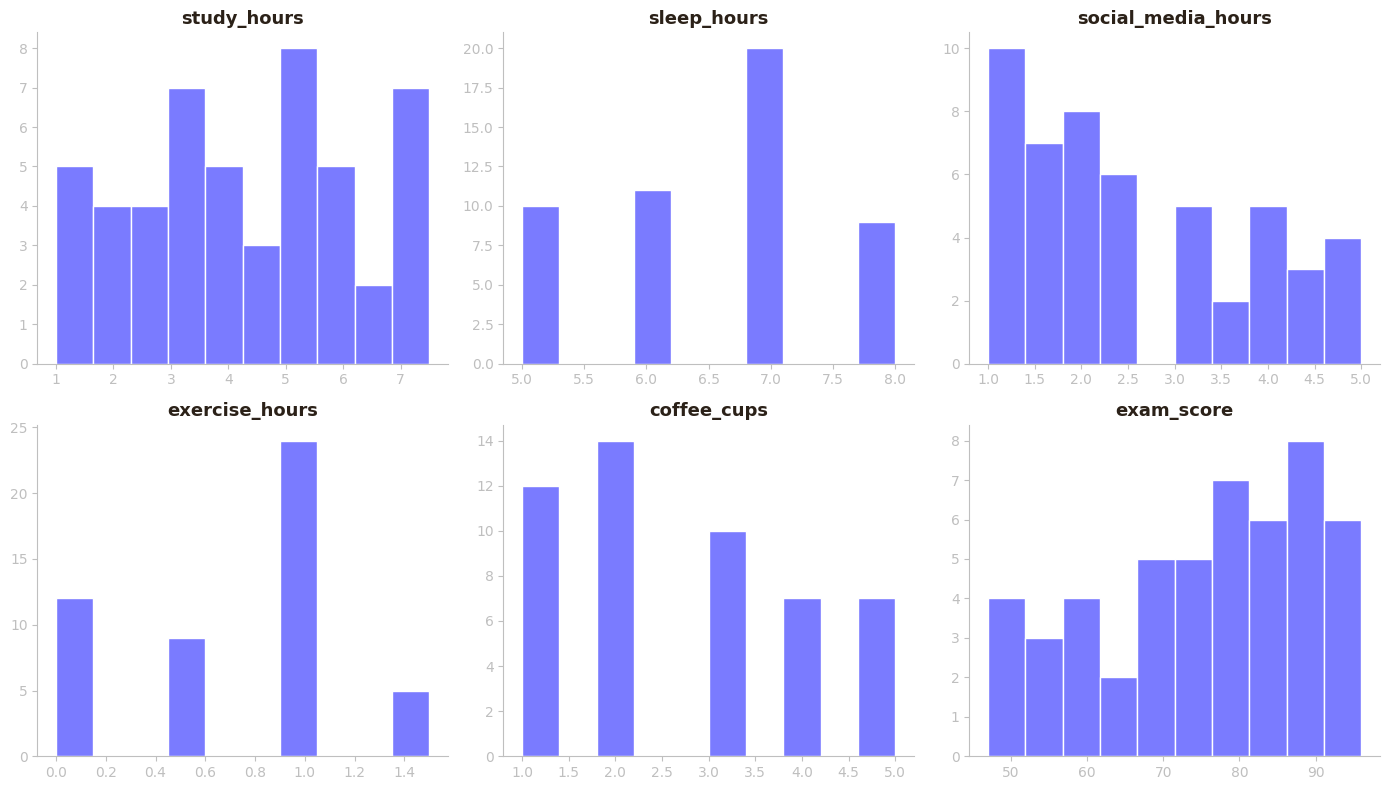

In [24]:
variables = ["study_hours", "sleep_hours", "social_media_hours",
             "exercise_hours", "coffee_cups", "exam_score"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, variable in enumerate(variables):
    axes[i].hist(dp[variable], bins=10, color=PURPLE, edgecolor="white")
    axes[i].set_title(variable)

plt.tight_layout()
plt.show()


**7.2 — Cada hábito frente a la nota de examen (scatter plots)**

Esto es la versión visual de la correlación que ya calculamos: cuanto más
"en línea recta" se vean los puntos, más fuerte es la relación.


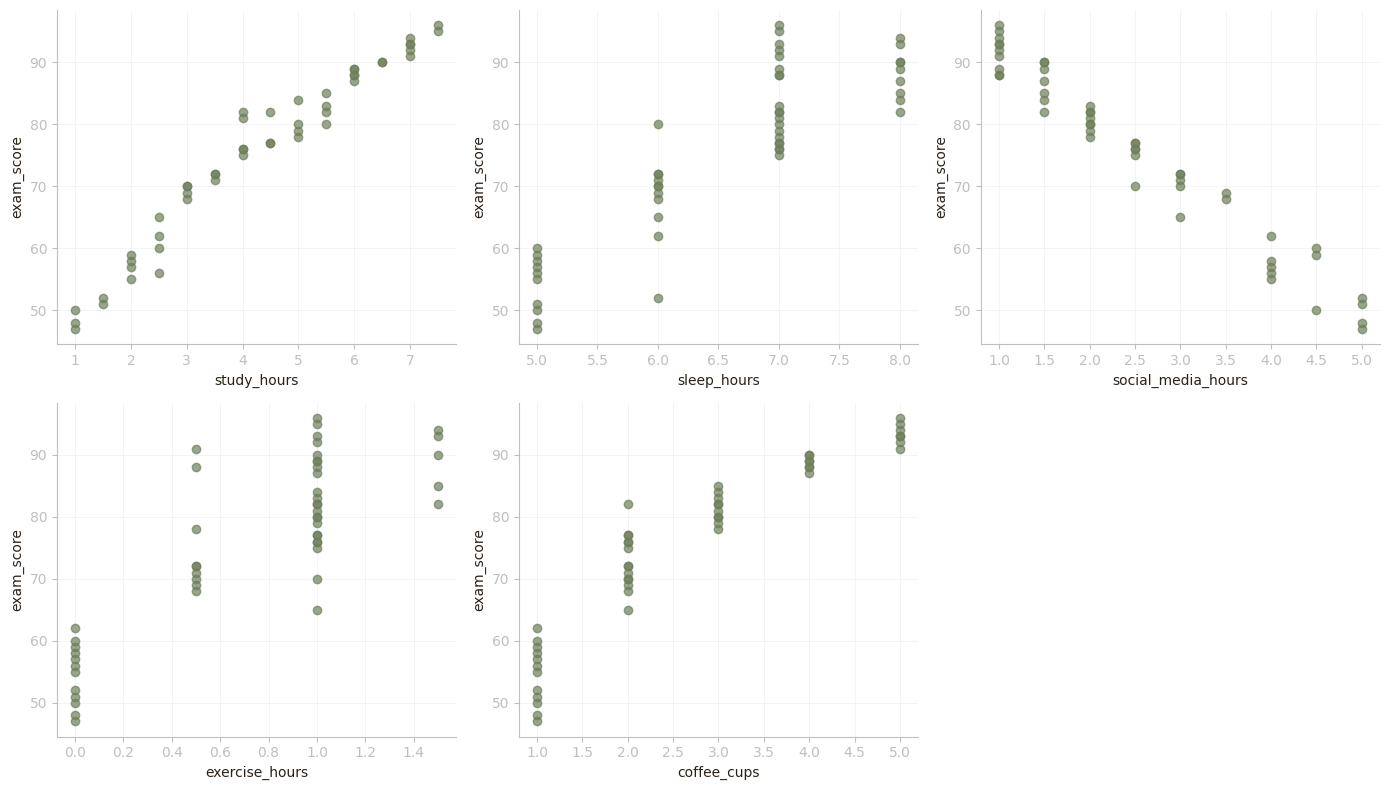

In [25]:
habitos = ["study_hours", "sleep_hours", "social_media_hours",
           "exercise_hours", "coffee_cups"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, habito in enumerate(habitos):
    axes[i].scatter(dp[habito], dp["exam_score"], alpha=0.7, color=GREEN)
    axes[i].set_xlabel(habito)
    axes[i].set_ylabel("exam_score")
    axes[i].grid(color="#f0f0f0", linewidth=0.5)
    axes[i].set_axisbelow(True)

axes[5].axis("off")

plt.tight_layout()
plt.show()


> 💡 Fíjate en la diferencia visual entre `study_hours` (sube la nota
> conforme suben las horas) y `social_media_hours` (baja la nota conforme
> suben las horas) — la misma relación que ya viste en los números de la
> correlación, ahora con la forma de la nube de puntos.


**7.3 — Mapa de calor de correlación**

La misma tabla de correlación de la sección 6, pero coloreada — más fácil
de leer de un vistazo.


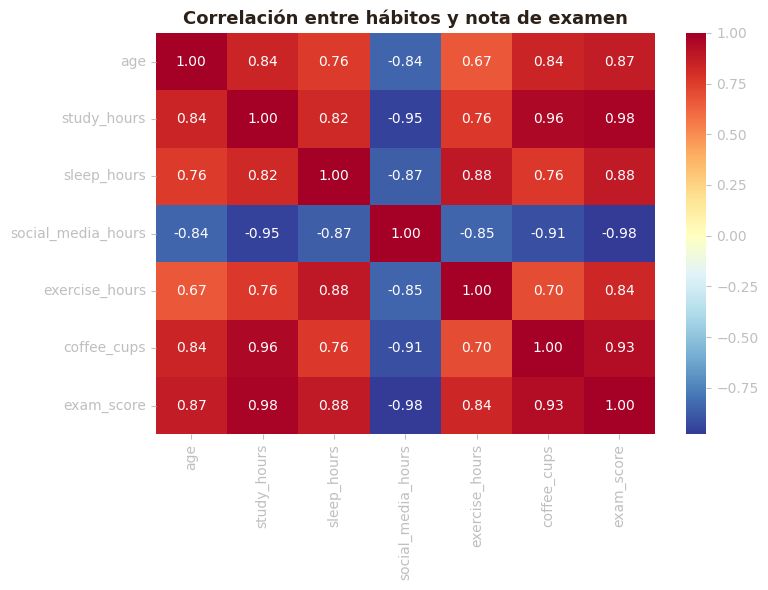

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=0,
    ax=ax
)
ax.set_title("Correlación entre hábitos y nota de examen")

plt.tight_layout()
plt.show()


**7.4 — Distribución de la nota dentro de cada calificación**

Comprueba que las 4 categorías que creamos con `pd.cut()` están bien
separadas: ninguna caja debería solaparse con la de al lado.


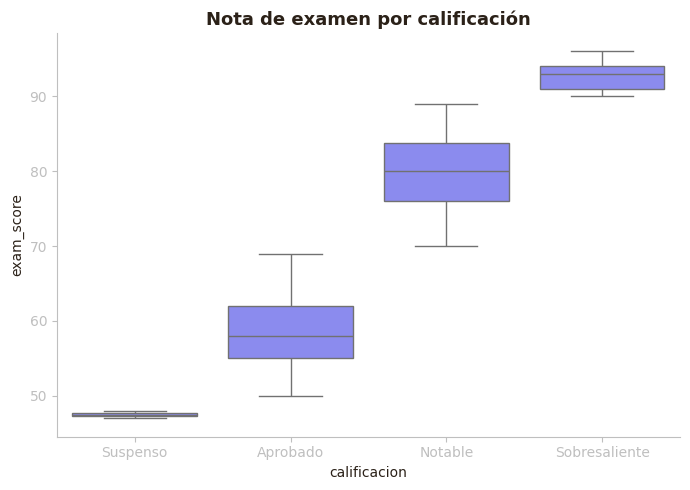

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    x="calificacion", y="exam_score", data=dp,
    order=["Suspenso", "Aprobado", "Notable", "Sobresaliente"],
    color=PURPLE,
    ax=ax,
)
ax.set_title("Nota de examen por calificación")

plt.tight_layout()
plt.show()


**7.5 — Nota media: estudia mucho vs. estudia poco**

La versión visual de la comparación de grupos de la sección 6.


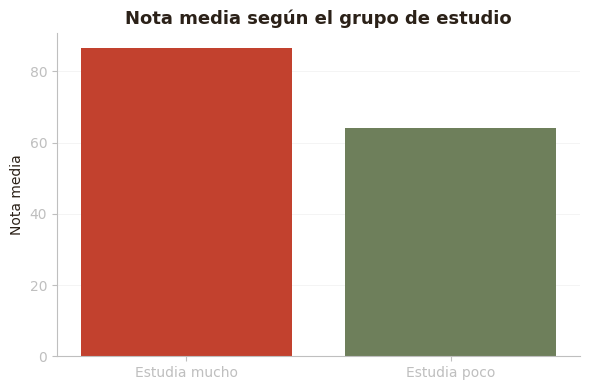

In [28]:
nota_media_grupo = dp.groupby("grupo_estudio")["exam_score"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(nota_media_grupo.index, nota_media_grupo.values, color=[RED, GREEN])
ax.set_title("Nota media según el grupo de estudio")
ax.set_ylabel("Nota media")
ax.grid(axis="y", color="#f0f0f0", linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


**7.6 — Extra: `pairplot` de Seaborn**

Un único comando que muestra, de golpe, la relación entre varias variables
a la vez (en la diagonal, la distribución de cada una; fuera de la
diagonal, los scatter plots cruzados).


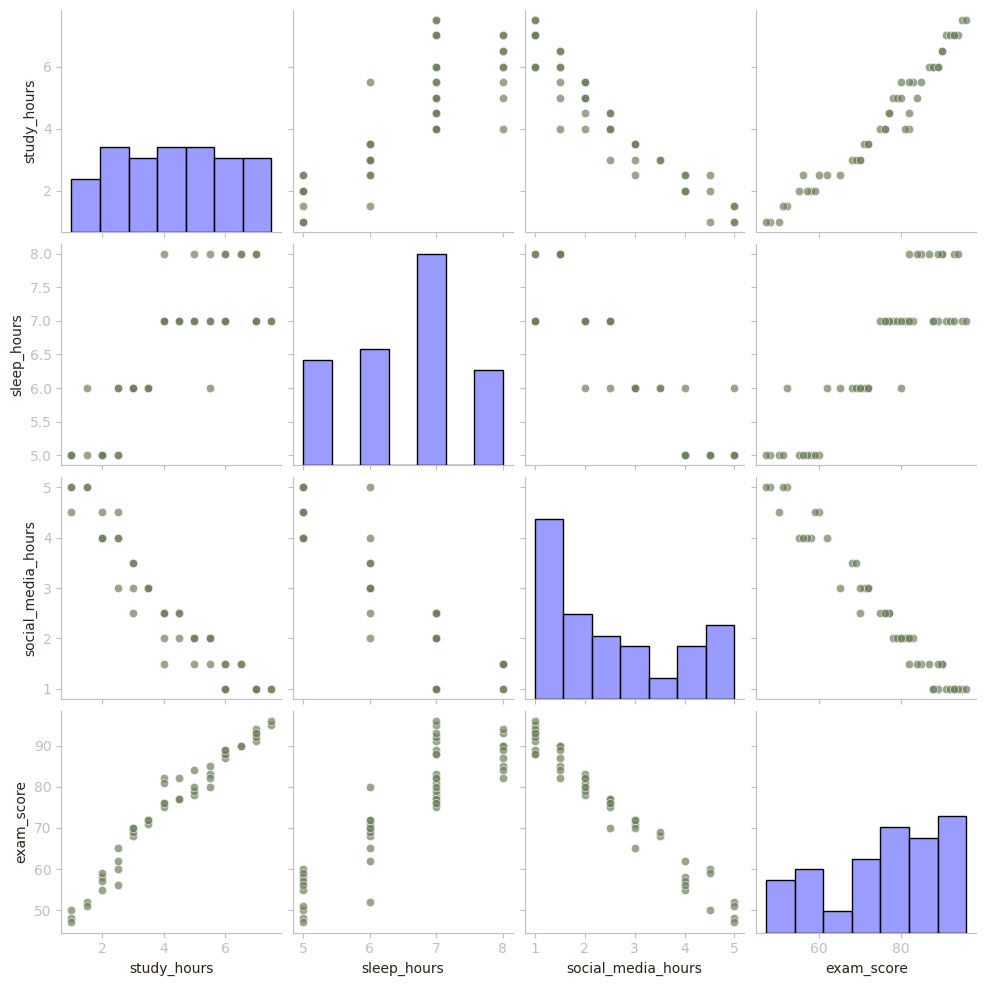

In [29]:
sns.pairplot(
    dp[["study_hours", "sleep_hours", "social_media_hours", "exam_score"]],
    plot_kws={"color": GREEN, "alpha": 0.7},
    diag_kws={"color": PURPLE}
)
plt.show()


---

## Insights y recomendaciones accionables

1. **Tutorías dirigidas por horas de estudio (impacto: alto, esfuerzo: bajo).**
   `study_hours` es, con diferencia, el hábito más relacionado con la nota (correlación
   0,98). Un umbral simple (estudiar por debajo de la mediana, ~4h/semana) permite al
   servicio de orientación identificar candidatos a tutoría sin necesidad de esperar a la
   primera nota de examen.
2. **Campaña de uso responsable de redes sociales (impacto: medio-alto, esfuerzo: bajo).**
   `social_media_hours` es la variable con correlación negativa más fuerte (-0,98). Los
   estudiantes de bajo rendimiento reportan una media de 4,9 h/día frente a 1,0 h/día en
   los de alto rendimiento — una diferencia lo bastante grande como para justificar una
   charla informativa dirigida, no solo una recomendación genérica.
3. **No intervenir sobre café ni sueño de forma aislada (impacto: bajo, esfuerzo: evitado).**
   Aunque `coffee_cups` y `sleep_hours` también correlacionan con la nota, es razonable
   sospechar que están arrastradas por su propia relación con `study_hours` (quien más
   estudia también duerme más y toma más café). Diseñar una intervención específica sobre
   estas variables sin primero controlar por horas de estudio arriesga gastar esfuerzo en
   la palanca equivocada.

### Limitaciones

- **Correlaciones inusualmente altas para el tamaño de muestra.** Con solo 50 estudiantes,
  correlaciones de 0,98 son más propias de una relación generada sintéticamente que de
  comportamiento humano real — en un dataset de producción esperaríamos relaciones más
  ruidosas. Estos resultados sirven para ilustrar la metodología, no como cifra a
  trasladar directamente a una población real sin repetir el análisis con datos nuevos.
- **Correlación no es causalidad.** El análisis no controla por variables de confusión
  razonables (dificultad de la asignatura, nivel socioeconómico, curso). Antes de basar
  una política de tutorías en estos resultados, convendría validar la relación con una
  muestra mayor y, si es posible, con datos longitudinales por estudiante.